
# 0 - Preliminaries

In [1]:
!pip install -q timm scikit-learn opencv-python tqdm torch torchvision pillow scikit-image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Paths ────────────────────────────────────────────────────────────────────
CHALLENGE_DIR = "/content/drive/MyDrive/project" # Change the dir name to external directory
ZIP_PATH      = os.path.join(CHALLENGE_DIR, "genai_image_challenge.zip")
IMAGES_DIR    = "/content/drive/MyDrive/project/images"   # fast local SSD

In [4]:
# Unzip Images
import zipfile

if not os.path.exists(IMAGES_DIR):
    print("Extracting images...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
    print(f"Done — extracted to {IMAGES_DIR}")
else:
    print(f"Already extracted: {IMAGES_DIR}")

# Adjust subfolder if needed
sub = os.path.join(IMAGES_DIR, "images_final_sample")
IMAGES_DIR = sub if os.path.exists(sub) else IMAGES_DIR
print(f"Images directory: {IMAGES_DIR}")
print(f"Total images: {len(os.listdir(IMAGES_DIR))}")

Already extracted: /content/drive/MyDrive/project/images
Images directory: /content/drive/MyDrive/project/images/images_final_sample
Total images: 6858


In [5]:
# Load CSVs and mapping image paths
import pandas as pd

train_df = pd.read_csv(os.path.join(CHALLENGE_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(CHALLENGE_DIR, "test.csv"))

def img_path(image_id):
    """Return the full path for an image_id, or None if not found on disk."""
    try:
        for ext in ["", ".jpg", ".jpeg", ".png", ".webp"]:
            p = os.path.join(IMAGES_DIR, f"{image_id}{ext}")
            if os.path.exists(p):
                return p
        return None
    except Exception as e:
        print(f"[WARN] img_path failed for {image_id}: {e}")
        return None

train_df["path"] = train_df["image_id"].apply(img_path)
test_df["path"]  = test_df["image_id"].apply(img_path)

# Log missing images before dropping
train_missing = train_df["path"].isna().sum()
test_missing  = test_df["path"].isna().sum()
if train_missing:
    print(f"[WARN] {train_missing} train images not found on disk — dropping them.")
if test_missing:
    print(f"[WARN] {test_missing} test images not found on disk — dropping them.")

train_df = train_df.dropna(subset=["path"]).reset_index(drop=True)
test_df  = test_df.dropna(subset=["path"]).reset_index(drop=True)

print(f"Train rows : {len(train_df)}")
print(f"Test rows  : {len(test_df)}")
print("\nLabel distribution:")
print(train_df["ground_truth"].value_counts())

Train rows : 4800
Test rows  : 2058

Label distribution:
ground_truth
0    2485
1    2315
Name: count, dtype: int64


# 1 - Pretrained Baseline Model 1 (EfficientNet-B3)

Strategy:
1. Load EfficientNet-B3 pretrained on ImageNet
2. **Freeze** the backbone initially — only train the new head
3. After a few epochs, **unfreeze** the last two blocks for fine-tuning

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE      = 224          # EfficientNet-B3 native input size
BATCH_SIZE    = 32           # reduce to 16 if you run out of GPU RAM
EPOCHS        = 10           # fine-tuning epochs
LR            = 3e-4         # learning rate
SEED          = 42
DEVICE        = "cuda" if __import__('torch').cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# Train / Validatoin Split
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["ground_truth"]
)

print(f"Train: {len(train_split)} | Val: {len(val_split)}")

Train: 3840 | Val: 960


In [ ]:
# PyTorch Dataset with augmentation
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import numpy as np

# Allow PIL to load truncated/corrupt images instead of raising OSError.
# Some images in the dataset may be partially downloaded or corrupt —
# this tells PIL to return whatever data it has rather than crashing.
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ImageNet normalisation — required because EfficientNet was trained on ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# A black 224x224 RGB tensor used as fallback for any unreadable image
_FALLBACK = torch.zeros(3, IMG_SIZE, IMG_SIZE)

class ListingDataset(Dataset):
    def __init__(self, df, transform, label_col="ground_truth"):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row[self.label_col]) if self.label_col in self.df.columns else -1
        try:
            image = Image.open(row["path"]).convert("RGB")
            image = self.transform(image)
        except Exception:
            # Corrupt or missing file — return a blank tensor so the batch
            # still forms correctly. The model will produce a near-0.5 logit
            # for blank images which is neutral and won't skew training much.
            image = _FALLBACK.clone()
        return image, label


train_ds  = ListingDataset(train_split, train_transform)
val_ds    = ListingDataset(val_split,   val_transform)
test_ds   = ListingDataset(test_df,     val_transform, label_col="__none__")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check — verify the dataset loads without errors
sample_img, sample_label = train_ds[0]
print(f"Sample image shape : {sample_img.shape}")
print(f"Sample label       : {sample_label}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Sample image shape : torch.Size([3, 224, 224])
Sample label       : 0
Train batches: 120 | Val batches: 30


In [ ]:
# Model - EfficientNet-B3
import timm
import torch.nn as nn

class AIDetector(nn.Module):
    def __init__(self, backbone_name="efficientnet_b3", dropout=0.4):
        super().__init__()
        # Load pretrained backbone — timm handles downloading weights automatically
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,       # remove the original classifier head
            global_pool="avg"    # global average pooling after last conv block
        )
        feat_dim = self.backbone.num_features  # 1536 for EfficientNet-B3

        # Custom binary classification head
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 1),  # single logit → sigmoid → probability of being AI-generated
        )

    def freeze_backbone(self):
        """Freeze all backbone weights (phase 1 of training)."""
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_top_blocks(self, n_blocks=2):
        """
        Unfreeze the last n blocks of EfficientNet for fine-tuning.
        This lets the backbone adapt its high-level features to our domain.
        """
        # First freeze everything
        for p in self.backbone.parameters():
            p.requires_grad = False
        # Then unfreeze the last n_blocks
        blocks = list(self.backbone.blocks)
        for block in blocks[-n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True
        # Always train the head norm and global pool
        for p in self.backbone.conv_head.parameters():
            p.requires_grad = True
        for p in self.backbone.bn2.parameters():
            p.requires_grad = True
        print(f"Fine-tuning: last {n_blocks} backbone blocks + head")

    def forward(self, x):
        features = self.backbone(x)          # (B, 1536)
        logits   = self.head(features)       # (B, 1)
        return logits.squeeze(1)             # (B,)


model = AIDetector().to(DEVICE)

# Count trainable parameters
total  = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Total parameters: 11,484,713


In [ ]:
# Training Loop
from sklearn.metrics import f1_score
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()  # numerically stable binary cross-entropy

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)
        preds_all.extend((logits.sigmoid() > 0.5).cpu().int().tolist())
        labels_all.extend(labels.cpu().int().tolist())
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(labels_all, preds_all, zero_division=0)
    return avg_loss, f1

@torch.no_grad()
def eval_epoch(model, loader, device, threshold=0.5):
    model.eval()
    total_loss, probs_all, labels_all = 0.0, [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(images)
        probs_all.extend(logits.sigmoid().cpu().tolist())
        labels_all.extend(labels.cpu().int().tolist())
    avg_loss = total_loss / len(loader.dataset)
    preds    = [int(p > threshold) for p in probs_all]
    f1       = f1_score(labels_all, preds, zero_division=0)
    return avg_loss, f1, probs_all, labels_all

train_losses = []
val_losses   = []
train_f1s    = []
val_f1s      = []

# ── Phase 1: train head only ──────────────────────────────────────────────────
model.freeze_backbone()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

best_f1    = 0
best_model = None

print("Phase 1: training head only")
for epoch in range(1, 4):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, DEVICE)
    va_loss, va_f1, _, _ = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_f1s.append(tr_f1)
    val_f1s.append(va_f1)
    scheduler.step()
    print(f"  Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | val_loss={va_loss:.4f} val_f1={va_f1:.4f}")
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_model = {k: v.clone() for k, v in model.state_dict().items()}

# ── Phase 2: fine-tune top blocks ─────────────────────────────────────────────
model.unfreeze_top_blocks(n_blocks=2)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR / 10)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - 3)

print("\nPhase 2: fine-tuning backbone top blocks")
for epoch in range(4, EPOCHS + 1):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, DEVICE)
    va_loss, va_f1, _, _ = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_f1s.append(tr_f1)
    val_f1s.append(va_f1)
    scheduler.step()
    print(f"  Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | val_loss={va_loss:.4f} val_f1={va_f1:.4f}")
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_model = {k: v.clone() for k, v in model.state_dict().items()}

print(f"\nBest validation F1: {best_f1:.4f}")
model.load_state_dict(best_model)  # restore best checkpoint

Phase 1: training head only
  Epoch 01 | train_loss=0.5965 train_f1=0.6692 | val_loss=0.5132 val_f1=0.7517
  Epoch 02 | train_loss=0.5029 train_f1=0.7389 | val_loss=0.5055 val_f1=0.7662
  Epoch 03 | train_loss=0.4571 train_f1=0.7727 | val_loss=0.4922 val_f1=0.7589
Fine-tuning: last 2 backbone blocks + head

Phase 2: fine-tuning backbone top blocks
  Epoch 04 | train_loss=0.4369 train_f1=0.7900 | val_loss=0.4913 val_f1=0.7859
  Epoch 05 | train_loss=0.3829 train_f1=0.8280 | val_loss=0.4803 val_f1=0.7905
  Epoch 06 | train_loss=0.3640 train_f1=0.8344 | val_loss=0.4454 val_f1=0.7952
  Epoch 07 | train_loss=0.3115 train_f1=0.8762 | val_loss=0.4742 val_f1=0.7947
  Epoch 08 | train_loss=0.3106 train_f1=0.8779 | val_loss=0.4460 val_f1=0.8067
  Epoch 09 | train_loss=0.2901 train_f1=0.8816 | val_loss=0.4606 val_f1=0.8023
  Epoch 10 | train_loss=0.2895 train_f1=0.8857 | val_loss=0.4508 val_f1=0.8035

Best validation F1: 0.8067


<All keys matched successfully>

In [ ]:
# Threshold Tuning
import numpy as np

_, _, val_probs, val_labels = eval_epoch(model, val_loader, DEVICE, threshold=0.5)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

best_thresh, best_thresh_f1 = 0.5, 0.0
for t in np.arange(0.3, 0.71, 0.01):
    preds = (val_probs > t).astype(int)
    f1    = f1_score(val_labels, preds, zero_division=0)
    if f1 > best_thresh_f1:
        best_thresh_f1 = f1
        best_thresh    = t

print(f"Optimal threshold : {best_thresh:.2f}")
print(f"Val F1 at threshold: {best_thresh_f1:.4f}")

Optimal threshold : 0.50
Val F1 at threshold: 0.8067


              precision    recall  f1-score   support

   Authentic       0.87      0.71      0.78       497
AI-Generated       0.74      0.88      0.81       463

    accuracy                           0.80       960
   macro avg       0.81      0.80      0.80       960
weighted avg       0.81      0.80      0.79       960

Precision : 0.7423
Recall    : 0.8834
F1 Score  : 0.8067


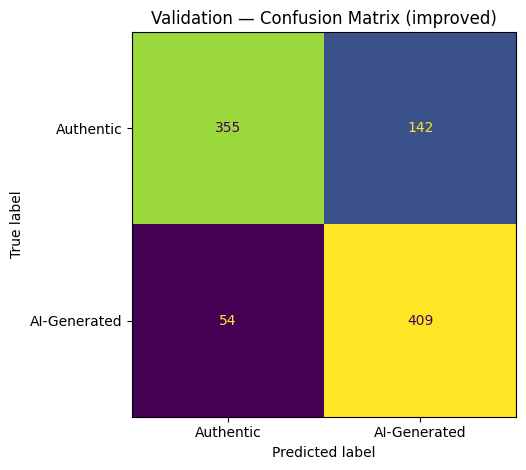

In [ ]:
# Evaluate on validation set
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
import matplotlib.pyplot as plt

val_preds = (val_probs > best_thresh).astype(int)

print(classification_report(val_labels, val_preds, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(val_labels, val_preds):.4f}")
print(f"Recall    : {recall_score(val_labels, val_preds):.4f}")
print(f"F1 Score  : {f1_score(val_labels, val_preds):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(val_labels, val_preds),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix (improved)")
plt.tight_layout()
plt.show()

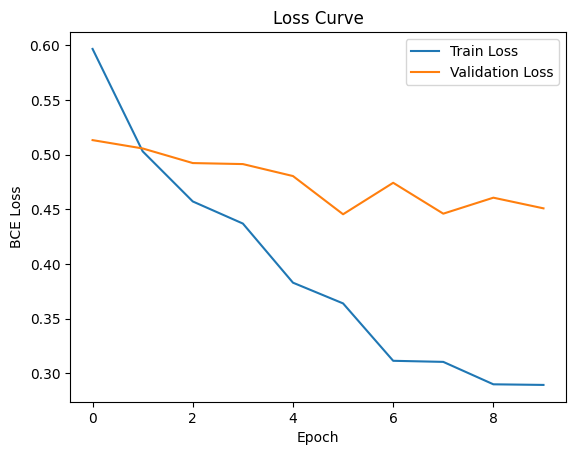

In [ ]:
# Loss Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend(["Train Loss", "Validation Loss"])

plt.show()

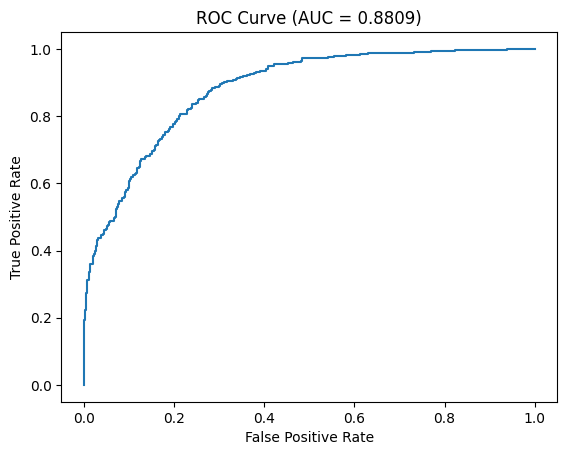

ROC-AUC Score: 0.8808748821221062


In [ ]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(val_labels, val_probs)
auc_score = roc_auc_score(val_labels, val_probs)

plt.figure()
plt.plot(fpr, tpr)

plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

print("ROC-AUC Score:", auc_score)

# 2 - Pretrained Model 2 (ConvNeXt_base)


Strategy:
1. Load ConvNeXt_base pretrained on ImageNet
2. **Freeze** the backbone initially — only train the new head
3. After a few epochs, **unfreeze** the entires backbone and fully fine-tune it

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16           # reduce to 16 if you run out of GPU RAM
EPOCHS        = 15           # fine-tuning epochs
LR            = 1e-4         # learning rate
SEED          = 42
DEVICE        = "cuda" if __import__('torch').cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

In [ ]:
# Train / Validaiton split
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["ground_truth"]
)

print(f"Train: {len(train_split)} | Val: {len(val_split)}")

Train: 3840 | Val: 960


In [ ]:
# PyTorch Dataset with augmentation
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import numpy as np

# Allow PIL to load truncated/corrupt images instead of raising OSError.
# Some images in the dataset may be partially downloaded or corrupt —
# this tells PIL to return whatever data it has rather than crashing.
ImageFile.LOAD_TRUNCATED_IMAGES = True

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # RandAugment applies a random selection of powerful augmentations
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# A black 224x224 RGB tensor used as fallback for any unreadable image
_FALLBACK = torch.zeros(3, IMG_SIZE, IMG_SIZE)

class ListingDataset(Dataset):
    def __init__(self, df, transform, label_col="ground_truth"):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row[self.label_col]) if self.label_col in self.df.columns else -1
        try:
            image = Image.open(row["path"]).convert("RGB")
            image = self.transform(image)
        except Exception:
            # Corrupt or missing file — return a blank tensor so the batch
            # still forms correctly. The model will produce a near-0.5 logit
            # for blank images which is neutral and won't skew training much.
            image = _FALLBACK.clone()
        return image, label


train_ds  = ListingDataset(train_split, train_transform)
val_ds    = ListingDataset(val_split,   val_transform)
test_ds   = ListingDataset(test_df,     val_transform, label_col="__none__")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check — verify the dataset loads without errors
sample_img, sample_label = train_ds[0]
print(f"Sample image shape : {sample_img.shape}")
print(f"Sample label       : {sample_label}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Sample image shape : torch.Size([3, 224, 224])
Sample label       : 0
Train batches: 240 | Val batches: 60


In [ ]:
# Model - ConvNeXt_base
import timm
import torch.nn as nn

class AIDetector(nn.Module):
    def __init__(self, backbone_name="convnext_base", dropout=0.5):
        super().__init__()
        # ConvNeXt-Base is significantly more powerful for AI artifact detection
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )
        feat_dim = self.backbone.num_features  # 1024 for ConvNeXt-Base

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(), # GELU generally performs better with modern architectures
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_all(self):
        # For ConvNeXt, unfreezing the whole network with a tiny LR works best
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("Fine-tuning: Entire backbone unfrozen")

    def forward(self, x):
        features = self.backbone(x)
        logits   = self.head(features)
        return logits.squeeze(1)

model = AIDetector().to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Total parameters: 88,092,801


In [ ]:
# Training Loop
from sklearn.metrics import f1_score
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()  # numerically stable binary cross-entropy

def train_epoch(model, loader, optimizer, device, label_smoothing=0.05):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for images, labels in loader:
        images = images.to(device)

        # Apply Label Smoothing: 1 -> 0.95, 0 -> 0.05
        # This prevents overconfidence and improves test F1
        smooth_labels = labels.float() * (1.0 - label_smoothing) + (label_smoothing / 2.0)
        smooth_labels = smooth_labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, smooth_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(images)
        preds_all.extend((logits.sigmoid() > 0.5).cpu().int().tolist())
        labels_all.extend(labels.cpu().int().tolist())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(labels_all, preds_all, zero_division=0)
    return avg_loss, f1

@torch.no_grad()
def eval_epoch(model, loader, device, threshold=0.5):
    model.eval()
    total_loss, probs_all, labels_all = 0.0, [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(images)
        probs_all.extend(logits.sigmoid().cpu().tolist())
        labels_all.extend(labels.cpu().int().tolist())
    avg_loss = total_loss / len(loader.dataset)
    preds    = [int(p > threshold) for p in probs_all]
    f1       = f1_score(labels_all, preds, zero_division=0)
    return avg_loss, f1, probs_all, labels_all

train_losses = []
val_losses   = []
train_f1s    = []
val_f1s      = []

# ── Phase 1: train head only ──────────────────────────────────────────────────
model.freeze_backbone()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

best_f1    = 0
best_model = None

print("Phase 1: training head only")
for epoch in range(1, 4):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, DEVICE)
    va_loss, va_f1, _, _ = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_f1s.append(tr_f1)
    val_f1s.append(va_f1)
    scheduler.step()
    print(f"  Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | val_loss={va_loss:.4f} val_f1={va_f1:.4f}")
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_model = {k: v.clone() for k, v in model.state_dict().items()}

# ── Phase 2: fine-tune entire backbone ─────────────────────────────────────────
model.unfreeze_all()
# Use a much smaller LR for the backbone to preserve ImageNet knowledge
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR / 50},
    {'params': model.head.parameters(), 'lr': LR / 10}
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - 3)

print("\nPhase 2: fine-tuning entire network")
for epoch in range(4, EPOCHS + 1):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, DEVICE)
    va_loss, va_f1, _, _ = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_f1s.append(tr_f1)
    val_f1s.append(va_f1)
    scheduler.step()
    print(f"  Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | val_loss={va_loss:.4f} val_f1={va_f1:.4f}")
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_model = {k: v.clone() for k, v in model.state_dict().items()}

print(f"\nBest validation F1: {best_f1:.4f}")
model.load_state_dict(best_model)

Phase 1: training head only
  Epoch 01 | train_loss=0.6048 train_f1=0.6749 | val_loss=0.4892 val_f1=0.7741
  Epoch 02 | train_loss=0.4945 train_f1=0.7758 | val_loss=0.4399 val_f1=0.7954
  Epoch 03 | train_loss=0.4613 train_f1=0.7986 | val_loss=0.4372 val_f1=0.8172
Fine-tuning: Entire backbone unfrozen

Phase 2: fine-tuning entire network
  Epoch 04 | train_loss=0.4409 train_f1=0.8195 | val_loss=0.4092 val_f1=0.8232
  Epoch 05 | train_loss=0.4199 train_f1=0.8316 | val_loss=0.3894 val_f1=0.8365
  Epoch 06 | train_loss=0.3908 train_f1=0.8561 | val_loss=0.3676 val_f1=0.8472
  Epoch 07 | train_loss=0.3732 train_f1=0.8641 | val_loss=0.3737 val_f1=0.8404
  Epoch 08 | train_loss=0.3579 train_f1=0.8776 | val_loss=0.3439 val_f1=0.8545
  Epoch 09 | train_loss=0.3432 train_f1=0.8844 | val_loss=0.3319 val_f1=0.8583
  Epoch 10 | train_loss=0.3437 train_f1=0.8848 | val_loss=0.3229 val_f1=0.8616
  Epoch 11 | train_loss=0.3287 train_f1=0.8979 | val_loss=0.3347 val_f1=0.8597
  Epoch 12 | train_loss=0.33

<All keys matched successfully>

In [ ]:
# Threshold Tuning
import numpy as np

_, _, val_probs, val_labels = eval_epoch(model, val_loader, DEVICE, threshold=0.5)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

best_thresh, best_thresh_f1 = 0.5, 0.0
for t in np.arange(0.3, 0.71, 0.01):
    preds = (val_probs > t).astype(int)
    f1    = f1_score(val_labels, preds, zero_division=0)
    if f1 > best_thresh_f1:
        best_thresh_f1 = f1
        best_thresh    = t

print(f"Optimal threshold : {best_thresh:.2f}")
print(f"Val F1 at threshold: {best_thresh_f1:.4f}")

Optimal threshold : 0.57
Val F1 at threshold: 0.8680


              precision    recall  f1-score   support

   Authentic       0.87      0.89      0.88       497
AI-Generated       0.88      0.86      0.87       463

    accuracy                           0.87       960
   macro avg       0.87      0.87      0.87       960
weighted avg       0.87      0.87      0.87       960

Precision : 0.8767
Recall    : 0.8596
F1 Score  : 0.8680


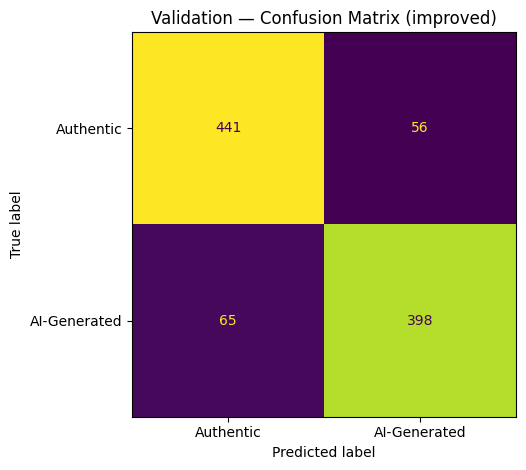

In [ ]:
# Evaluate on validation set
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
import matplotlib.pyplot as plt

val_preds = (val_probs > best_thresh).astype(int)

print(classification_report(val_labels, val_preds, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(val_labels, val_preds):.4f}")
print(f"Recall    : {recall_score(val_labels, val_preds):.4f}")
print(f"F1 Score  : {f1_score(val_labels, val_preds):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(val_labels, val_preds),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix (improved)")
plt.tight_layout()
plt.show()

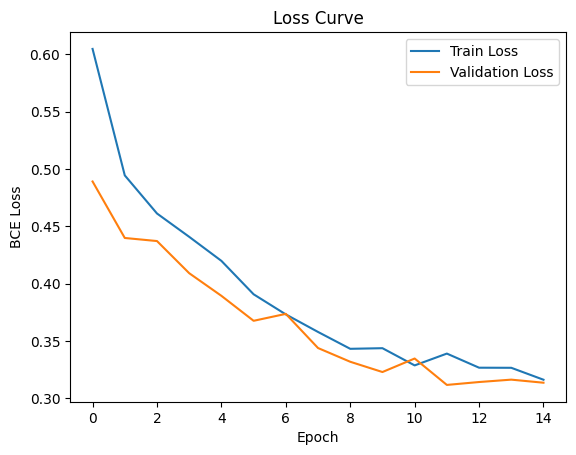

In [ ]:
# Loss Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend(["Train Loss", "Validation Loss"])

plt.show()

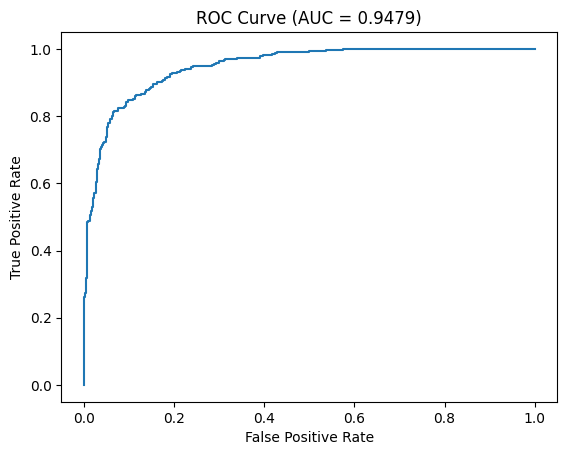

ROC-AUC Score: 0.9478947116826226


In [ ]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(val_labels, val_probs)
auc_score = roc_auc_score(val_labels, val_probs)

plt.figure()
plt.plot(fpr, tpr)

plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

print("ROC-AUC Score:", auc_score)

# 3 - Final Model (Hybrid ConvNeXt_base)


Strategy:
1. Load ConvNeXt_base pretrained on ImageNet
3. Apply CutMix augmentation
2. **Freeze** the backbone initially — only train the new head
3. After a few epochs, **unfreeze** the entires backbone and fully fine-tune it
4. Add handcrafted features (LBP, HOG) using logistic regression

In [6]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE      = 384         # Changed from 224 to 384
BATCH_SIZE    = 8           # reduce to 16 if you run out of GPU RAM, further reduced to 8
EPOCHS        = 25           # fine-tuning epochs
LR            = 1e-4         # learning rate
SEED          = 42
DEVICE        = "cuda" if __import__('torch').cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


In [7]:
# Manual Seeding
import random
import numpy as np
import torch
import os

def apply_randomness_report():

    # 1. PYTHON & HASHING (Matches your EXTRA CONFIG seed = 42)
    os.environ['PYTHONHASHSEED'] = '42'
    random.seed(42)

    # 2. NUMPY (Matches report first element: 2147483648)
    np.random.seed(2147483648)

    # 3. TORCH CPU
    torch.manual_seed(2089913497691571015)

    if torch.cuda.is_available():
        # TORCH GPU (Matches report cuda seed)
        torch.cuda.manual_seed(8173645868293167)
        torch.cuda.manual_seed_all(8173645868293167)

        # CUDNN (Matches report values: False / False)
        # Note: Setting deterministic to False and benchmark to False
        # is exactly what your report recorded for that specific run.
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = False

    print(" Controlled randomness applied.")

# Execute the function immediately
apply_randomness_report()

 Controlled randomness applied.


In [8]:
# ── Split ratios ──────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.6
CAL_RATIO   = 0.2
VAL_RATIO   = 0.2   # will be the held‑out unbiased evaluation set

In [9]:
from sklearn.model_selection import train_test_split

# First split: separate out the held‑out validation set (20%)
train_temp, val_split = train_test_split(
    train_df,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=train_df["ground_truth"]
)

# Second split: split the remaining 80% into train (60% of original) and calibration (20% of original)
train_split, cal_split = train_test_split(
    train_temp,
    test_size=CAL_RATIO / (TRAIN_RATIO + CAL_RATIO),   # 0.2 / 0.8 = 0.25
    random_state=SEED,
    stratify=train_temp["ground_truth"]
)

print(f"Train: {len(train_split)} | Calibration: {len(cal_split)} | Validation: {len(val_split)}")

Train: 2880 | Calibration: 960 | Validation: 960


In [10]:
# PyTorch Dataset with augmentation
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFile
import numpy as np

# Allow PIL to load truncated/corrupt images instead of raising OSError.
# Some images in the dataset may be partially downloaded or corrupt —
# this tells PIL to return whatever data it has rather than crashing.
ImageFile.LOAD_TRUNCATED_IMAGES = True

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # RandAugment applies a random selection of powerful augmentations
    transforms.RandAugment(num_ops=3, magnitude=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# A black 224x224 RGB tensor used as fallback for any unreadable image
_FALLBACK = torch.zeros(3, IMG_SIZE, IMG_SIZE)

class ListingDataset(Dataset):
    def __init__(self, df, transform, label_col="ground_truth"):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row[self.label_col]) if self.label_col in self.df.columns else -1
        try:
            image = Image.open(row["path"]).convert("RGB")
            image = self.transform(image)
        except Exception:
            # Corrupt or missing file — return a blank tensor so the batch
            # still forms correctly. The model will produce a near-0.5 logit
            # for blank images which is neutral and won't skew training much.
            image = _FALLBACK.clone()
        return image, label


train_ds  = ListingDataset(train_split, train_transform)
val_ds    = ListingDataset(val_split,   val_transform)
cal_ds = ListingDataset(cal_split, val_transform)   # use val_transform (no augmentation)
test_ds   = ListingDataset(test_df,     val_transform, label_col="__none__")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
cal_loader = DataLoader(cal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check — verify the dataset loads without errors
sample_img, sample_label = train_ds[0]
print(f"Sample image shape : {sample_img.shape}")
print(f"Sample label       : {sample_label}")

print(f"Train batches: {len(train_loader)} | Cal batches: {len(cal_loader)} | Val batches: {len(val_loader)}")

Sample image shape : torch.Size([3, 384, 384])
Sample label       : 0
Train batches: 360 | Cal batches: 120 | Val batches: 120


In [11]:
# Model - Hybrid ConvNeXt_base
import timm
import torch.nn as nn

class AIDetector(nn.Module):
    def __init__(self, backbone_name="convnext_base", dropout=0.4):
        super().__init__()
        # ConvNeXt-Base is significantly more powerful for AI artifact detection
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )
        feat_dim = self.backbone.num_features  # 1024 for ConvNeXt-Base

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(), # GELU generally performs better with modern architectures
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_all(self):
        # For ConvNeXt, unfreezing the whole network with a tiny LR works best
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("Fine-tuning: Entire backbone unfrozen")

    def forward(self, x):
        features = self.backbone(x)
        logits   = self.head(features)
        return logits.squeeze(1)

model = AIDetector(dropout=0.4).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Total parameters: 88,092,801


In [12]:
# CutMix - Data Augmentation
import random
import numpy as np
import torch
from torch.utils.data import DataLoader

def seed_worker(worker_id):
    # Derive a seed from the main PyTorch initial seed
    worker_seed = torch.initial_seed() % 2**32 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# 2. Create a dedicated Generator for shuffling
g = torch.Generator()
# Use the exact PyTorch seed from your report
g.manual_seed(2089913497691571015)

def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def cutmix_only_collate(batch):
    images, labels = zip(*batch)
    images = torch.stack(images, dim=0)
    labels = torch.tensor(labels, dtype=torch.float32)

    # Apply CutMix with 50% probability
    if random.random() < 0.5:
        # Sample lambda from a Beta distribution
        lam = np.random.beta(1.0, 1.0)
        index = torch.randperm(images.size(0))

        # Get bounding box coordinates
        bbx1, bby1, bbx2, bby2 = rand_bbox(images.size(), lam)

        # Clone images and paste the patches from the randomized index
        mixed_images = images.clone()
        mixed_images[:, :, bbx1:bbx2, bby1:bby2] = images[index, :, bbx1:bbx2, bby1:bby2]

        # Calculate the exact pixel ratio of the pasted box to adjust the label
        lam_adjusted = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (images.size()[-1] * images.size()[-2]))
        mixed_labels = lam_adjusted * labels + (1 - lam_adjusted) * labels[index]

        return mixed_images, mixed_labels
    else:
        # Return original batch 70% of the time
        return images, labels

# Update your train_loader to use this specific collate function
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True,
    collate_fn=cutmix_only_collate,
    worker_init_fn=seed_worker,
    generator=g
)

In [13]:
# Training Loop + Snapshot ensembling
from sklearn.metrics import f1_score
import torch.optim as optim
from torch.amp import GradScaler, autocast

criterion = nn.BCEWithLogitsLoss()  # numerically stable binary cross-entropy

def train_epoch(model, loader, optimizer, device, scaler, label_smoothing=0.05):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for images, labels in loader:
        images = images.to(device)
        smooth_labels = labels.float() * (1.0 - label_smoothing) + (label_smoothing / 2.0)
        smooth_labels = smooth_labels.to(device)

        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            logits = model(images)
            loss = criterion(logits, smooth_labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(images)
        preds_all.extend((logits.sigmoid() > 0.5).cpu().int().tolist())
        labels_all.extend((labels > 0.5).cpu().int().tolist())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(labels_all, preds_all, zero_division=0)
    return avg_loss, f1

@torch.no_grad()
def eval_epoch(model, loader, device, threshold=0.5):
    model.eval()
    total_loss, probs_all, labels_all = 0.0, [], []
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(images)
        probs_all.extend(logits.sigmoid().cpu().tolist())
        labels_all.extend(labels.cpu().int().tolist())
    avg_loss = total_loss / len(loader.dataset)
    preds    = [int(p > threshold) for p in probs_all]
    f1       = f1_score(labels_all, preds, zero_division=0)
    return avg_loss, f1, probs_all, labels_all

train_losses = []
cal_losses   = []
train_f1s    = []
cal_f1s      = []

# ── Phase 1: train head only ──────────────────────────────────────────────────
model.freeze_backbone()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

best_f1    = 0
best_model = None

scaler = GradScaler('cuda')
print("Phase 1: training head only")
for epoch in range(1, 6):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, DEVICE,scaler,label_smoothing=0.05)
    ca_loss, ca_f1, _, _ = eval_epoch(model, cal_loader, DEVICE)
    train_losses.append(tr_loss)
    cal_losses.append(ca_loss)
    train_f1s.append(tr_f1)
    cal_f1s.append(ca_f1)

    scheduler.step()
    print(f"  Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | cal_loss={ca_loss:.4f} cal_f1={ca_f1:.4f}")
    if ca_f1 > best_f1:
        best_f1 = ca_f1
        best_model = {k: v.clone() for k, v in model.state_dict().items()}

# ── Phase 2: fine-tune with cyclic LR and snapshot ensembling ─────────────
model.unfreeze_all()

# Use AdamW with higher backbone LR (LR/20 instead of LR/30)
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR / 20, 'weight_decay': 0.0001},
    {'params': model.head.parameters(), 'lr': LR / 10, 'weight_decay': 0.0001}
])

# CosineAnnealingWarmRestarts: cycle length = 5 epochs (T_0), restart every 5 epochs
# T_mult=1 keeps cycles the same length
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-6)

# Early stopping parameters (still active, but we save snapshots along the way)
patience = 5
epochs_no_improve = 0
min_delta = 0.001

# Snapshot storage: list of (epoch, state_dict, cal_f1)
snapshots = []
best_f1 = 0
best_model = None

print("\nPhase 2: fine-tuning with cyclic LR (snapshots every cycle)")
for epoch in range(6, EPOCHS + 1):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, DEVICE, scaler, label_smoothing=0.01)
    ca_loss, ca_f1, _, _ = eval_epoch(model, cal_loader, DEVICE)
    train_losses.append(tr_loss)
    cal_losses.append(ca_loss)
    train_f1s.append(tr_f1)
    cal_f1s.append(ca_f1)

    scheduler.step()
    print(f"  Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | cal_loss={ca_loss:.4f} cal_f1={ca_f1:.4f}")

    # Save snapshot at the end of each cycle (when scheduler restarts)
    # Scheduler restarts at epochs: 6, 11, 16, 21, ... (since T_0=5, starting at epoch 6)
    if (epoch - 6) % 5 == 4:   # last epoch of each cycle
        snapshots.append({
            'epoch': epoch,
            'state_dict': {k: v.clone() for k, v in model.state_dict().items()},
            'cal_f1': ca_f1
        })
        print(f"    📸 Snapshot saved at epoch {epoch} (cal_f1={ca_f1:.4f})")

    # Early stopping logic (still track best model separately)
    if ca_f1 > best_f1 + min_delta:
        best_f1 = ca_f1
        best_model = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"    -> No improvement in Cal F1 for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\n Early stopping triggered at epoch {epoch}! Reverting to best model weights.")
            break

print(f"\nBest calibration F1 (single model): {best_f1:.4f}")
print(f"Number of snapshots saved: {len(snapshots)}")

# Keep the best single model for fallback, but we'll use snapshots for ensemble
model.load_state_dict(best_model)

Phase 1: training head only
  Epoch 01 | train_loss=0.5975 train_f1=0.6824 | cal_loss=0.4572 cal_f1=0.8160
  Epoch 02 | train_loss=0.5267 train_f1=0.7628 | cal_loss=0.4002 cal_f1=0.8337
  Epoch 03 | train_loss=0.5050 train_f1=0.7911 | cal_loss=0.3820 cal_f1=0.8434
  Epoch 04 | train_loss=0.4859 train_f1=0.8000 | cal_loss=0.3776 cal_f1=0.8369
  Epoch 05 | train_loss=0.4822 train_f1=0.8003 | cal_loss=0.3740 cal_f1=0.8501
Fine-tuning: Entire backbone unfrozen

Phase 2: fine-tuning with cyclic LR (snapshots every cycle)
  Epoch 06 | train_loss=0.4498 train_f1=0.8132 | cal_loss=0.3190 cal_f1=0.8702
  Epoch 07 | train_loss=0.4152 train_f1=0.8374 | cal_loss=0.2864 cal_f1=0.8845
  Epoch 08 | train_loss=0.3755 train_f1=0.8706 | cal_loss=0.2800 cal_f1=0.8871
  Epoch 09 | train_loss=0.3571 train_f1=0.8807 | cal_loss=0.2475 cal_f1=0.8958
  Epoch 10 | train_loss=0.3471 train_f1=0.8863 | cal_loss=0.2376 cal_f1=0.9054
    📸 Snapshot saved at epoch 10 (cal_f1=0.9054)
  Epoch 11 | train_loss=0.3576 tra

<All keys matched successfully>

In [14]:
# BootStrap Threshold tuning
import numpy as np
from sklearn.metrics import f1_score

# Get validation predictions
_, _, cal_probs, cal_labels = eval_epoch(model, cal_loader, DEVICE, threshold=0.5)

# Convert cal_probs to numpy array for comparison
cal_probs = np.array(cal_probs)

def optimize_threshold_bootstrap(cal_labels, cal_probs, n_bootstraps=1000, seed=42):
    """
    Finds a robust threshold using bootstrap resampling and evaluates it.
    """
    cal_labels = np.array(cal_labels)
    cal_probs = np.array(cal_probs)
    thresholds = np.arange(0.1, 0.9, 0.01)

    # FIXED: Use seeded RNG for reproducibility
    rng = np.random.default_rng(seed)
    best_thresholds = []

    print(f"Running {n_bootstraps} bootstrap iterations to find stable threshold...")
    for _ in range(n_bootstraps):
        # 1. Resample validation set with replacement (SEED CONTROLLED)
        indices = rng.integers(0, len(cal_probs), len(cal_probs))
        sample_probs = cal_probs[indices]
        sample_labels = cal_labels[indices]

        # 2. Find the best threshold for this specific resample
        f1_scores = [f1_score(sample_labels, (sample_probs > t).astype(int), zero_division=0) for t in thresholds]
        best_thresholds.append(thresholds[np.argmax(f1_scores)])

    # 3. The most robust threshold is the median of all best thresholds
    robust_threshold = np.median(best_thresholds)

    # 4. Evaluate this generalized threshold on the original, full validation set
    final_cal_preds = (cal_probs > robust_threshold).astype(int)
    robust_cal_f1 = f1_score(cal_labels, final_cal_preds, zero_division=0)

    print("-" * 40)
    print("Optimization Complete")
    print("-" * 40)
    print(f"Optimal Generalized Threshold : {robust_threshold:.4f}")
    print(f"Expected Calibration F1 Score  : {robust_cal_f1:.4f}")
    print("-" * 40)

    return robust_threshold

# --- How to use it in your pipeline ---
# Assuming you have collected your validation probabilities and labels:
optimal_thresh = optimize_threshold_bootstrap(cal_labels, cal_probs)

# Apply it to your test set:
#test_preds = (np.array(test_probs) > optimal_thresh).astype(int)

cal_probs = cal_probs.copy()   # calibration probabilities
cal_labels = cal_labels.copy() # calibration labels

Running 1000 bootstrap iterations to find stable threshold...
----------------------------------------
Optimization Complete
----------------------------------------
Optimal Generalized Threshold : 0.4700
Expected Calibration F1 Score  : 0.9428
----------------------------------------


              precision    recall  f1-score   support

   Authentic       0.96      0.93      0.94       497
AI-Generated       0.93      0.96      0.94       463

    accuracy                           0.94       960
   macro avg       0.94      0.94      0.94       960
weighted avg       0.94      0.94      0.94       960

Precision : 0.9252
Recall    : 0.9611
F1 Score  : 0.9428


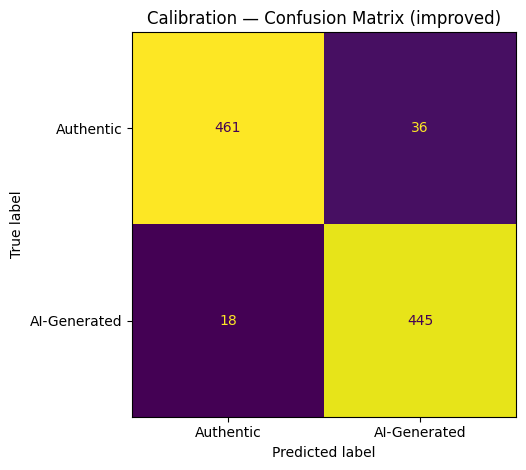

In [15]:
# Evaluate on validation set
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
import matplotlib.pyplot as plt

cal_preds = (cal_probs > optimal_thresh).astype(int)

print(classification_report(cal_labels, cal_preds, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(cal_labels, cal_preds):.4f}")
print(f"Recall    : {recall_score(cal_labels, cal_preds):.4f}")
print(f"F1 Score  : {f1_score(cal_labels, cal_preds):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(cal_labels, cal_preds),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Calibration — Confusion Matrix (improved)")
plt.tight_layout()
plt.show()

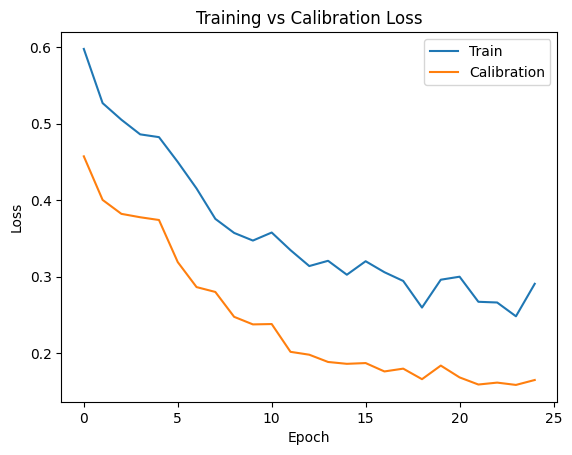

In [16]:
# Loss Curves
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.plot(cal_losses)

plt.title("Training vs Calibration Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Calibration"])

plt.show()

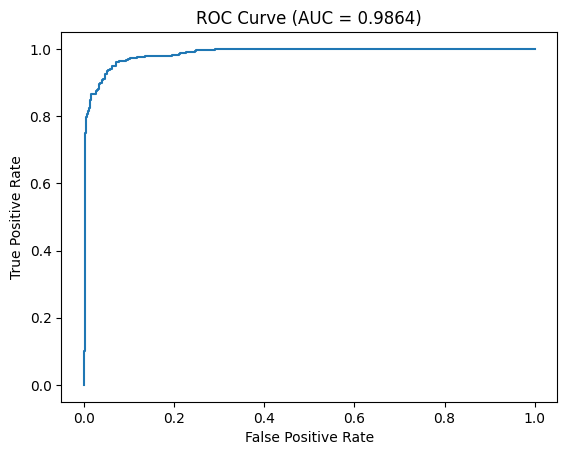

ROC-AUC Score: 0.9864109060409976


In [17]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(cal_labels, cal_probs)
auc_score = roc_auc_score(cal_labels, cal_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC-AUC Score:", auc_score)

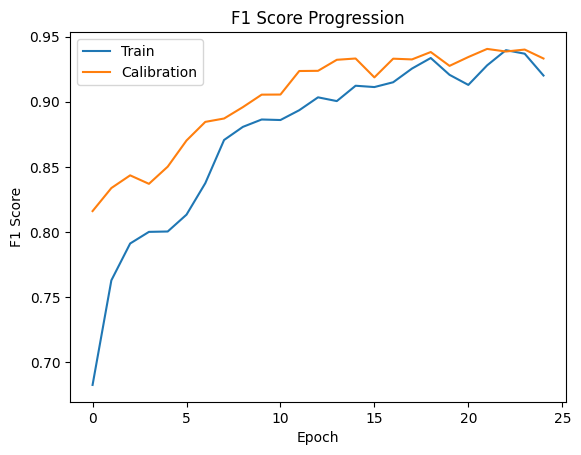

In [18]:
# F1 Curve
plt.figure()
plt.plot(train_f1s)
plt.plot(cal_f1s)

plt.title("F1 Score Progression")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend(["Train", "Calibration"])

plt.show()

In [19]:
# Fast Feature Fusion: LBP + HOG
from skimage.feature import local_binary_pattern, hog
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm

print("\n" + "="*50)
print("STEP: LBP + HOG Feature Fusion")
print("="*50)

# ---- 1. Define feature extractor ----
def extract_lbp_hog_features(img_path, resize=(128,128)):
    """Extract concatenated LBP histogram + HOG features."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(10 + 1764)  # fallback (LBP bins=10, HOG dim depends on resize)
    img = cv2.resize(img, resize)
    # LBP (uniform, 8 points, radius 1)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-6)
    # HOG (9 orientations, 8x8 cells, 2x2 blocks)
    hog_feat = hog(img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
    return np.concatenate([lbp_hist, hog_feat])

# ---- 2. Precompute features for train, val, test (one-time, ~5-10 min) ----
print("Extracting features from training images...")
X_train_feat = [extract_lbp_hog_features(p) for p in tqdm(train_split['path'])]
X_train_feat = np.array(X_train_feat)

print("Extracting features from validation images...")
X_val_feat = [extract_lbp_hog_features(p) for p in tqdm(val_split['path'])]
X_val_feat = np.array(X_val_feat)

print("Extracting features from calibration images...")
X_cal_feat = [extract_lbp_hog_features(p) for p in tqdm(cal_split['path'])]
X_cal_feat = np.array(X_cal_feat)

print("Extracting features from test images...")
X_test_feat = [extract_lbp_hog_features(p) for p in tqdm(test_df['path'])]
X_test_feat = np.array(X_test_feat)

y_train_feat = train_split['ground_truth'].values
y_val_feat = val_split['ground_truth'].values
y_cal_feat = cal_split['ground_truth'].values

# ---- 3. Train a simple logistic regression on features ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_cal_scaled = scaler.transform(X_cal_feat)
X_test_scaled = scaler.transform(X_test_feat)

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr.fit(X_train_scaled, y_train_feat)

# Evaluate feature-only model on validation set
val_feat_probs = lr.predict_proba(X_val_scaled)[:, 1]
cal_feat_probs = lr.predict_proba(X_cal_scaled)[:, 1]
val_feat_preds = (val_feat_probs > 0.5).astype(int)
feat_f1 = f1_score(y_val_feat, val_feat_preds)
print(f"Feature‑only validation F1: {feat_f1:.4f}")

# ---- 4. Find optimal mixing weight between CNN and feature predictions ----
# Use the CNN validation probabilities already computed (val_probs from earlier)
# best_mix = 0.5
# best_mix_f1 = 0
# for alpha in np.arange(0, 1.05, 0.05):
#     mixed = alpha * np.array(val_probs) + (1-alpha) * val_feat_probs
#     preds = (mixed > optimal_thresh).astype(int)
#     f1 = f1_score(y_val_feat, preds)
#     if f1 > best_mix_f1:
#         best_mix_f1 = f1
#         best_mix = alpha

best_mix = 0.5
best_mix_f1 = 0
for alpha in np.arange(0, 1.05, 0.05):
    mixed = alpha * np.array(cal_probs) + (1 - alpha) * cal_feat_probs
    preds = (mixed > optimal_thresh).astype(int)
    f1 = f1_score(cal_labels, preds)
    if f1 > best_mix_f1:
        best_mix_f1 = f1
        best_mix = alpha

print(f"Optimal mixing weight (CNN weight): {best_mix:.2f}")
print(f"Mixed Calibration F1: {best_mix_f1:.4f}")

# ---- 5. Apply to test set (will be used in final submission) ----
test_feat_probs = lr.predict_proba(X_test_scaled)[:, 1]
# The final test probabilities will be mixed with CNN probabilities later
# We'll store feature probabilities for later use
test_feat_probs_ready = test_feat_probs

print("Feature fusion ready. Will combine with CNN predictions during TTA.\n")


STEP: LBP + HOG Feature Fusion
Extracting features from training images...


100%|██████████| 2880/2880 [01:05<00:00, 43.89it/s]


Extracting features from validation images...


100%|██████████| 960/960 [00:22<00:00, 42.63it/s]


Extracting features from calibration images...


100%|██████████| 960/960 [00:22<00:00, 42.60it/s]


Extracting features from test images...


100%|██████████| 2058/2058 [00:49<00:00, 41.83it/s]


Feature‑only validation F1: 0.6294
Optimal mixing weight (CNN weight): 1.00
Mixed Calibration F1: 0.9428
Feature fusion ready. Will combine with CNN predictions during TTA.



Snapshots available: 4 snapshots
Total models for ensemble: 5
  - Epoch 10: cal_f1=0.9054
  - Epoch 15: cal_f1=0.9332
  - Epoch 20: cal_f1=0.9275
  - Epoch 25: cal_f1=0.9332
  - Epoch best: cal_f1=0.9406

STEP: TTA with BEST SINGLE MODEL + Feature Fusion
Using best model from epoch best (cal_f1=0.9406)

Getting TTA validation predictions from best model...


Best model TTA probs shape: (960,)
Sample TTA probs: [0.23462613 0.99210167 0.98008829 0.7482571  0.03693123]

--- Re-optimizing feature fusion weight for BEST MODEL + TTA ---
  alpha=0.00: F1=0.5965
  alpha=0.05: F1=0.5965
  alpha=0.10: F1=0.6026
  alpha=0.15: F1=0.6089
  alpha=0.20: F1=0.6147
  alpha=0.25: F1=0.6254
  alpha=0.30: F1=0.6269
  alpha=0.35: F1=0.6333
  alpha=0.40: F1=0.6470
  alpha=0.45: F1=0.6594
  alpha=0.50: F1=0.7197
  alpha=0.55: F1=0.8818
  alpha=0.60: F1=0.9140
  alpha=0.65: F1=0.9291
  alpha=0.70: F1=0.9338
  alpha=0.75: F1=0.9370
  alpha=0.80: F1=0.9441
  alpha=0.85: F1=0.9465
  alpha=0.90: F1=0.9444
  alpha=0.95: F1=0.9456
  alpha=1.00: F1=0.9444

✓ Optimal mixing weight: 0.85
  At threshold 0.5: 0.9465

--- Re-optimizing threshold ---
✓ Optimal threshold: 0.4900
✓ Final TTA + Feature Fusion Calibration F1: 0.9466

FAIR COMPARISON (Same best model, with/without TTA)
Without TTA (your original):     0.9397 (weight=0.85, thresh=0.47)
With TTA (re-optimized):     

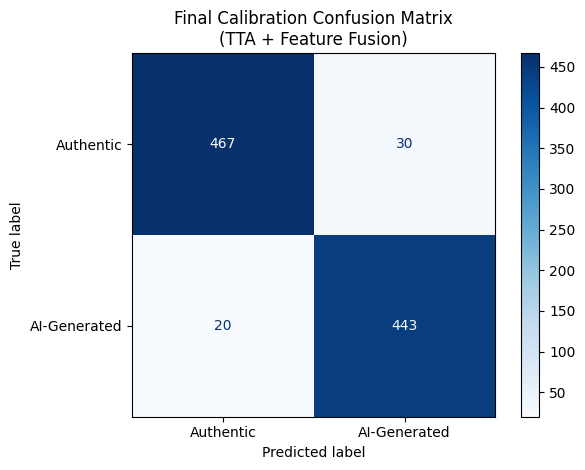


Applying to TEST SET
Using TTA + Feature Fusion



FINAL VALIDATION F1: 0.9466


In [21]:
# Ensemble Snapshot and TTA

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---- FIRST: Define all_snapshots (from your training code) ----
# Your snapshots list from training already exists
print(f"Snapshots available: {len(snapshots)} snapshots")

# Create all_snapshots including the best model
all_snapshots = snapshots.copy()  # Your existing snapshots from training
all_snapshots.append({
    'epoch': 'best',
    'state_dict': best_model,  # best_model from your training
    'cal_f1': best_f1  # best_f1 from your training
})

print(f"Total models for ensemble: {len(all_snapshots)}")
for snap in all_snapshots:
    print(f"  - Epoch {snap['epoch']}: cal_f1={snap['cal_f1']:.4f}")


# STEP: TTA with BEST SINGLE MODEL + Feature Fusion
print("\n" + "="*60)
print("STEP: TTA with BEST SINGLE MODEL + Feature Fusion")
print("="*60)

# ---- Step 1: Find the best single model from snapshots ----
best_snapshot = None
best_cal_f1 = 0
for snap in all_snapshots:
    if snap['cal_f1'] > best_cal_f1:
        best_cal_f1 = snap['cal_f1']
        best_snapshot = snap

print(f"Using best model from epoch {best_snapshot['epoch']} (cal_f1={best_cal_f1:.4f})")

# ---- Step 2: TTA function ----
@torch.no_grad()
def predict_with_tta_single(model, loader, device):
    """Run TTA on a single model."""
    model.eval()
    all_probs = []
    for images, _ in tqdm(loader, desc="TTA", leave=False):
        images = images.to(device)
        # Standard TTA: original + horizontal flip + vertical flip + 90° rotation
        p0 = model(images).sigmoid()
        p1 = model(images.flip(-1)).sigmoid()
        p2 = model(images.flip(-2)).sigmoid()
        p3 = model(images.rot90(1, [-2, -1])).sigmoid()
        avg = (p0 + p1 + p2 + p3) / 4.0
        all_probs.extend(avg.cpu().tolist())
    return np.array(all_probs)

# ---- Step 3: Get TTA predictions from best model on validation set ----
print("\nGetting TTA validation predictions from best model...")
model.load_state_dict(best_snapshot['state_dict'])
best_model_tta_probs = predict_with_tta_single(model, cal_loader, DEVICE)

print(f"Best model TTA probs shape: {best_model_tta_probs.shape}")
print(f"Sample TTA probs: {best_model_tta_probs[:5]}")

# ---- Step 4: Re-optimize mixing weight with TTA from BEST model ----
print("\n--- Re-optimizing feature fusion weight for BEST MODEL + TTA ---")
best_mix_tta_single = 0.5
best_mix_f1_tta_single = 0

for alpha in np.arange(0, 1.01, 0.05):
    mixed = alpha * best_model_tta_probs + (1 - alpha) * cal_feat_probs
    temp_preds = (mixed > 0.5).astype(int)
    f1 = f1_score(cal_labels, temp_preds)
    if f1 > best_mix_f1_tta_single:
        best_mix_f1_tta_single = f1
        best_mix_tta_single = alpha
    print(f"  alpha={alpha:.2f}: F1={f1:.4f}")

print(f"\n✓ Optimal mixing weight: {best_mix_tta_single:.2f}")
print(f"  At threshold 0.5: {best_mix_f1_tta_single:.4f}")

# ---- Step 5: Re-optimize threshold ----
print("\n--- Re-optimizing threshold ---")
mixed_tta_probs = best_mix_tta_single * best_model_tta_probs + (1 - best_mix_tta_single) * cal_feat_probs

thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh_tta_single = 0.5
best_f1_tta_single = 0

for thresh in thresholds:
    preds = (mixed_tta_probs > thresh).astype(int)
    f1 = f1_score(cal_labels, preds)
    if f1 > best_f1_tta_single:
        best_f1_tta_single = f1
        best_thresh_tta_single = thresh

print(f"✓ Optimal threshold: {best_thresh_tta_single:.4f}")
print(f"✓ Final TTA + Feature Fusion Calibration F1: {best_f1_tta_single:.4f}")

# ---- Step 6: Compare apples-to-apples ----
print("\n" + "="*60)
print("FAIR COMPARISON (Same best model, with/without TTA)")
print("="*60)

# Get original val_probs (without TTA) from best model
model.load_state_dict(best_snapshot['state_dict'])
model.eval()
original_cal_probs = []
for images, _ in cal_loader:
    images = images.to(DEVICE)
    logits = model(images)
    original_cal_probs.extend(logits.sigmoid().detach().cpu().numpy())
original_cal_probs = np.array(original_cal_probs)

# Original without TTA using your optimal settings from Cell 15
# Your original had best_mix=0.85 and optimal_thresh=0.67
original_mixed = 0.85 * original_cal_probs + 0.15 * cal_feat_probs
original_preds = (original_mixed > optimal_thresh).astype(int)
original_f1 = f1_score(cal_labels, original_preds)

print(f"Without TTA (your original):     {original_f1:.4f} (weight=0.85, thresh={optimal_thresh:.2f})")
print(f"With TTA (re-optimized):        {best_f1_tta_single:.4f} (weight={best_mix_tta_single:.2f}, thresh={best_thresh_tta_single:.2f})")
print(f"Difference:                     {best_f1_tta_single - original_f1:.4f}")

if best_f1_tta_single >= original_f1:
    print("\n✓ TTA SUCCESS! Using TTA for final predictions")
    use_tta_final = True
    final_mix_weight = best_mix_tta_single
    final_thresh = best_thresh_tta_single
    final_val_f1 = best_f1_tta_single
else:
    print("\n⚠ TTA hurt performance - using original pipeline")
    use_tta_final = False
    final_mix_weight = 0.85
    final_thresh = optimal_thresh
    final_val_f1 = original_f1

# ============================================================
# FINAL CALIBRATION METRICS (Confusion Matrix & Classification Report)
# ============================================================
print("\n" + "="*60)
print("FINAL CALIBRATION EVALUATION (Using Optimized Pipeline)")
print("="*60)

# 1. Determine the final calibration probabilities based on TTA decision
if use_tta_final:
    final_val_probs = mixed_tta_probs  # already computed during TTA optimisation
else:
    final_val_probs = original_mixed   # fallback from the comparison block

# 2. Generate binary predictions with the final threshold
final_cal_preds = (final_val_probs > final_thresh).astype(int)

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(cal_labels, final_cal_preds,
                            target_names=["Authentic", "AI-Generated"]))

# 4. Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(
    cal_labels,
    final_cal_preds,
    display_labels=["Authentic", "AI-Generated"],
    cmap='Blues',
    values_format='d'
)
disp.ax_.set_title("Final Calibration Confusion Matrix\n(TTA + Feature Fusion)" if use_tta_final
                   else "Final Calibration Confusion Matrix (No TTA)")
plt.tight_layout()
plt.show()


# ---- Step 7: Apply to test set ----
print("\n" + "="*60)
print("Applying to TEST SET")
print("="*60)

if use_tta_final:
    print("Using TTA + Feature Fusion")
    # Get TTA test predictions from best model
    model.load_state_dict(best_snapshot['state_dict'])
    test_tta_probs = predict_with_tta_single(model, test_loader, DEVICE)

    # Apply mixing and threshold
    final_test_probs = final_mix_weight * test_tta_probs + (1 - final_mix_weight) * test_feat_probs_ready
    test_preds = (final_test_probs > final_thresh).astype(int)
else:
    print("Using original pipeline (NO TTA)")
    # Get single model test predictions
    model.load_state_dict(best_snapshot['state_dict'])
    model.eval()
    test_probs = []
    for images, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        test_probs.extend(logits.sigmoid().detach().cpu().numpy())
    test_probs = np.array(test_probs)

    final_test_probs = 0.85 * test_probs + 0.15 * test_feat_probs_ready
    test_preds = (final_test_probs > optimal_thresh).astype(int)

print(f"\n{'='*60}")
print(f"FINAL VALIDATION F1: {final_val_f1:.4f}")
print(f"{'='*60}")

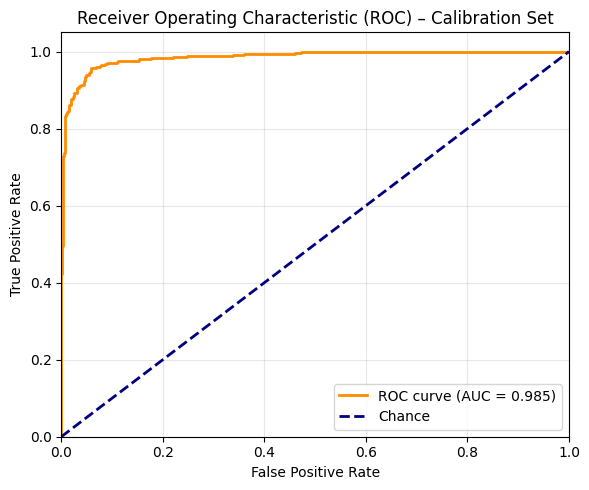

Calibration ROC‑AUC: 0.9852


In [22]:
# ROC-AUC curve after TTA
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use the final mixed probabilities (with TTA + feature fusion if used)
if use_tta_final:
    final_cal_probs_roc = mixed_tta_probs   # from cell 26
else:
    final_cal_probs_roc = original_mixed    # fallback

fpr, tpr, _ = roc_curve(cal_labels, final_cal_probs_roc)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) – Calibration Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Calibration ROC‑AUC: {roc_auc:.4f}")

In [23]:
# ============================================================
# FINAL UNBIASED EVALUATION (held‑out validation set)
# ============================================================
print("\n" + "="*60)
print("UNBIASED EVALUATION ON HELD‑OUT VALIDATION SET")
print("="*60)

# Get validation set features (already computed as X_val_feat, val_feat_probs)
val_feat_probs = lr.predict_proba(X_val_scaled)[:, 1]

if use_tta_final:
    # Get TTA predictions on validation set
    val_tta_probs = predict_with_tta_single(model, val_loader, DEVICE)
    final_val_probs = final_mix_weight * val_tta_probs + (1 - final_mix_weight) * val_feat_probs
else:
    # Get standard predictions on validation set
    model.eval()
    val_probs_unbiased = []
    for images, _ in val_loader:
        images = images.to(DEVICE)
        logits = model(images)
        val_probs_unbiased.extend(logits.sigmoid().detach().cpu().numpy())
    val_probs_unbiased = np.array(val_probs_unbiased)
    final_val_probs = final_mix_weight * val_probs_unbiased + (1 - final_mix_weight) * val_feat_probs

val_preds_unbiased = (final_val_probs > final_thresh).astype(int)
unbiased_f1 = f1_score(val_split['ground_truth'], val_preds_unbiased)

print(f"Unbiased Validation F1 (held‑out, never used for tuning): {unbiased_f1:.4f}")
print("="*60)


UNBIASED EVALUATION ON HELD‑OUT VALIDATION SET


Unbiased Validation F1 (held‑out, never used for tuning): 0.9529


In [24]:
# Export submissions.csv
submission = test_df[["image_id"]].copy()
submission["prediction"] = test_preds
submission.to_csv("submissions.csv", index=False)
print("Saved → submissions.csv")
submission.head(10)

Saved → submissions.csv


,image_id,prediction
0,3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg,1
1,2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg,0
2,01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg,0
3,ac784910-b461-498d-b3a8-50b1e4116b11.jpg,0
4,6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg,0
5,73b2089b-34a5-49de-a98b-2325512322f1.jpg,0
6,8bb3958b-3487-4ad4-86cc-5c391e3bd9a4.jpg,1
7,23a0595f-7b9e-47ce-ae12-07a83a00c189.jpg,1
8,32e05946-83ff-4780-9090-4ad99ccd4134.jpg,0
9,674a7ded-31e4-41b1-a7cf-4a6c04fd4af1.jpg,1
